This project walks through the different stages of approaching a classification problem, from **exploratory data analysis** to **model selection**.

The Data set used here was obtained from the *Predicting Loan Payback* [Kaggle competition](https://www.kaggle.com/competitions/playground-series-s5e11/rules#7.-data-access-and-use). The data are used in accordance with the Apache 2.0 license and competition rules.

The specific environment used is available [here](https://github.com/znogbes/kaggle-predicting-loan-payback/blob/main/environment.yml)

# Data import

The block below downloads data directly to a data directory using the Kaggle API. The data only needs downloading from Kaggle once, so the `try except` statement checks whether data files are present in the data directory already (e.g., when we do a re-run of the script).

<details markdown="1">
<summary><b>Show code</b></summary>

In [1]:
# set up
import pandas as pd
import kaggle
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

# upload data
try:
    # if already downloaded, just read csv
    data_train = pd.read_csv("data/train.csv")

except FileNotFoundError:
    # if downloading for the first time
    import os
    from kaggle.api.kaggle_api_extended import KaggleApi
    import zipfile

    # authenticate
    api = KaggleApi()
    api.authenticate()

    # download data
    # data directory
    data_dir = "./data/"
    # ensure directory exists
    os.makedirs(data_dir, exist_ok=True)

    api.competition_download_files(competition='playground-series-s5e11',
                                   path=data_dir)
    
    with zipfile.ZipFile("data/playground-series-s5e11.zip", 'r') as zip_ref:
        zip_ref.extractall("data/")
    
    data_train = pd.read_csv("data/train.csv")

</details>

# Exploratory data analysis 

This particular data set was created synthetically, so we wouldn't expect common data quality issues such as missing values. You can validate this is indeed the case - by checking the number of non-null values (which is equal to the number of entries, or rows). 

In [2]:
# data exploration (train data)
data_train.columns.to_list()
data_train.info() # no missing values in any columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


## **What's the breakdown of the outcome variable?**

`loan_paid_back` has been coded as 0's (non-payers) and 1's (payers). Before we do any exploratory analysis on features, it's useful to know how balanced (or not) the outcome we will predict is.

**Spoiler alert:** the outcome is unbalanced in this data set (almost 80% of the sample paid their loan back)

In [3]:
# payback outcome breakdown
pd.DataFrame({
    'n': data_train['loan_paid_back'].value_counts().map('{:,}'.format),
    'percentage': 100*data_train['loan_paid_back'].value_counts(normalize=True).round(3)
    })

,n,percentage
loan_paid_back,,
1.0,"474,494",79.9
0.0,"119,500",20.1


## **Numerical features**

The raw data set is small, but representative of the mix of numeric and categorical variables we can see in real-life data sets. We'll start exploring numeric features of the data by checking their distribution with the `describe()` method. Note that before we do that, we drop the `id` variable as it has no utility for modelling because it's a unique row identifier. Similarly, we exclude the outcome variable, as this step is concerned with features only.

In [14]:
# permanently remove id col
data_train.drop('id', inplace=True, axis=1)

# exploratory data analysis - numeric variables
# drop dependent variable (as it's been coded as 1 and 0)
data_train.describe().drop('loan_paid_back', axis=1)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000


The table above already offers insights on the data. As expected from variables that describe financial information, we can tell, by looking at the standard deviations and range of values (min and max), that most of these variables have a right or left skew. However, presenting this table to non-technical stakeholders might be overwhelming, so **we'll proceed visualise this information**. While we're at it, let's compare the outcome groups (payers vs. non-payers). 

You can either use box plots or histograms to visualise the distribution of numeric variables. In my opinion, the choice of which to use might depend of which audience will be seeing this. I would go for box plots if presenting to a non-technical audience, but use histograms with technical audiences.

### **Box plots**

Below, I have:
- divided the data by outcome group
- selected numeric features
- looped through each feature (in the split data sets)
- drawn box plots using `matplotlib`

*Note:* I have made the bars horizontal and made the whiskers represent minimum and maximum values for the corresponding outcome group. I think those choices improve readability for non-technical stakeholders.

<details markdown="1">
<summary><b>Show code</b></summary>

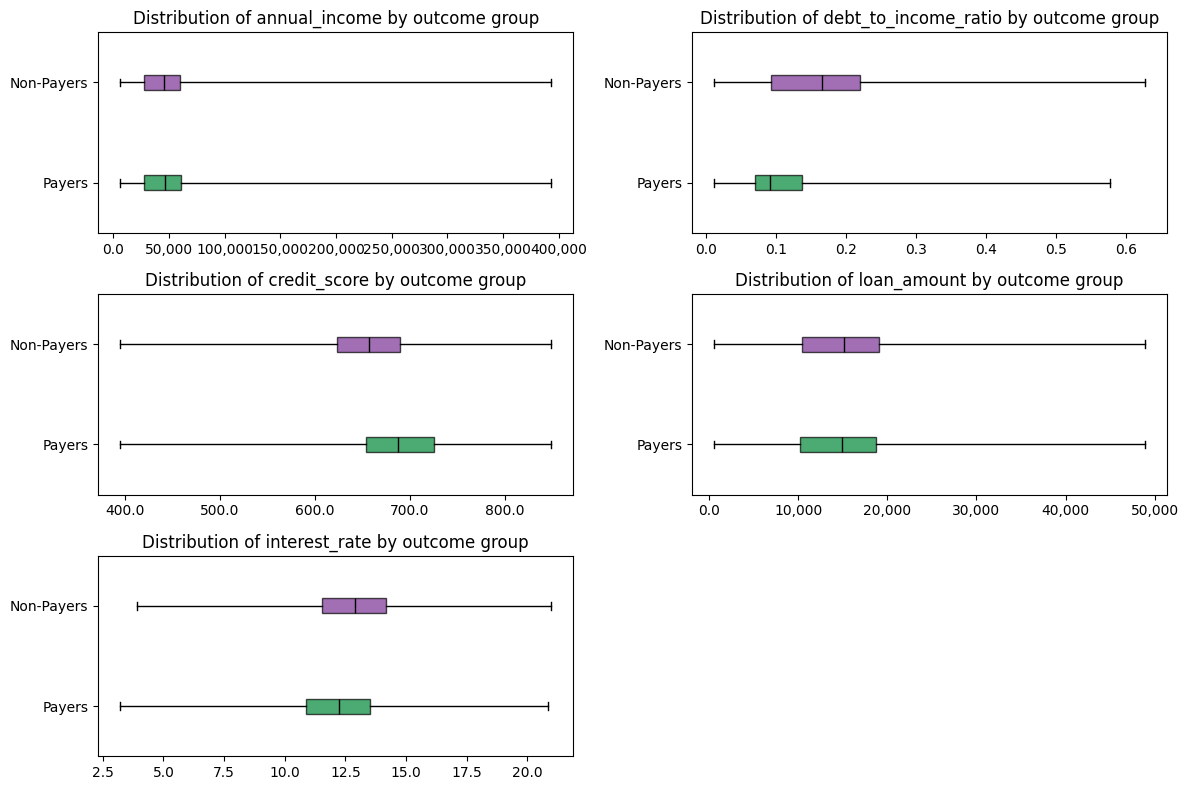

In [ ]:
# create df's by payback group 
filter = data_train['loan_paid_back'] == 1
data_train_payers = data_train[filter]
filter = data_train['loan_paid_back'] == 0
data_train_non_payers = data_train[filter]

# visualisation of numeric variables
# define cols to loop through in plot
numeric_cols = data_train_payers.select_dtypes(
    include=np.number).columns.drop('loan_paid_back')
# determine grid size
num_cols = len(numeric_cols)
ncols = 2
nrows = int(np.ceil(num_cols/2)) # in case of single row/col

# define plot objects
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
axes = axes.flatten()

# make boxplots
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create boxplot for col
    bp = ax.boxplot(
        [data_train_payers[col], data_train_non_payers[col]],
        labels=['Payers', 'Non-Payers'],
        # allow custom colours 
        patch_artist=True,
        # horizontal orientation of bars
        vert=False,
        # make whiskers represent min and max values
        whis = (0, 100)
        )
    
    colours = ['#008837', '#7b3294']
    for patch, colour in zip(bp['boxes'], colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set(color='black')
    
    ax.set_title(f"Distribution of {col} by outcome group")
    ax.get_xaxis().set_major_formatter(
        # custom format for large/small scales
        mtick.FuncFormatter(lambda x, p: format(x, ',.0f') if x >=1000 else
        # use commas for large scales, 1 decimal for small scales 
                            format(x, '.1f'))
                            )
 
# hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

</details>

### **Histograms**

I think these are a better fit for technical audiences, particularly if you're discussing skews in the data or considering transformations to the data. 

<details markdown="1">
<summary><b>Show code</b></summary>

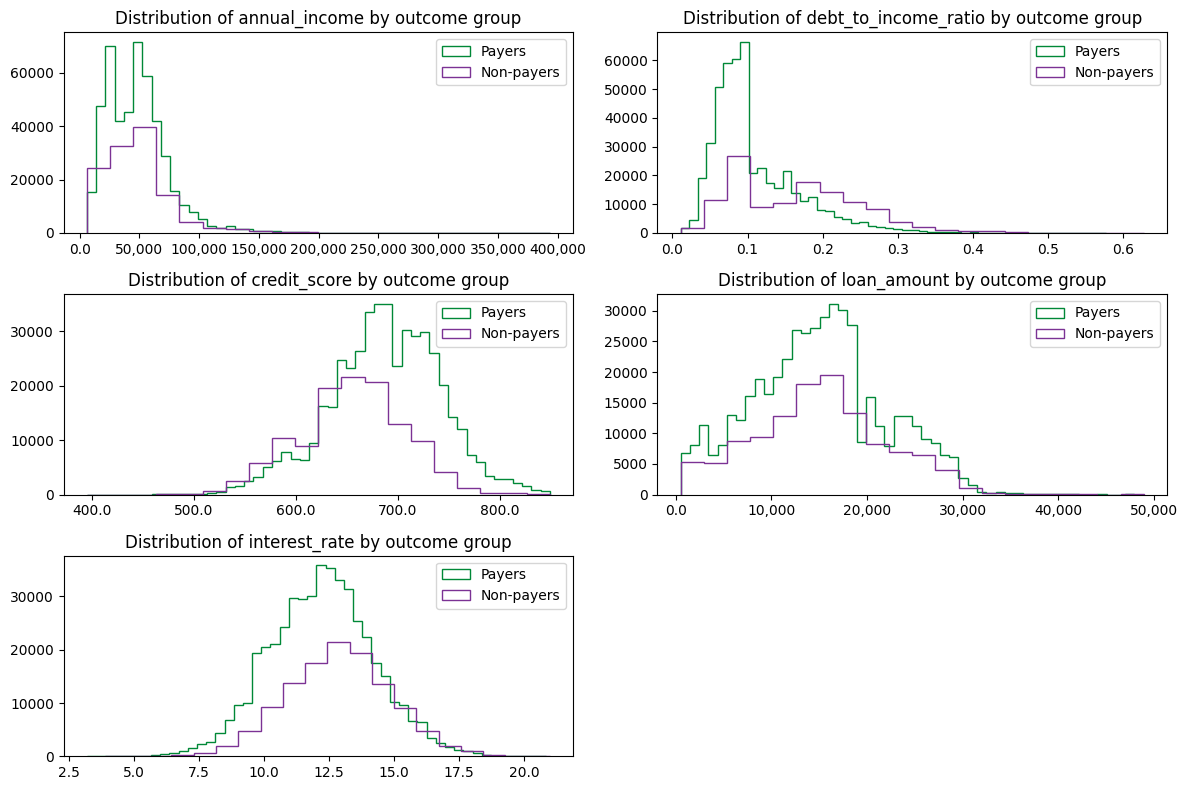

In [ ]:
# alternatively, these variables can also be visualised as histograms
fig, axes = plt.subplots(nrows,ncols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    # create histograms for each group
    ax.hist(
        data_train_payers[col], bins=50,  
        color='#008837',
        label='Payers', 
        histtype = 'step'
        )
        
    ax.hist(
        data_train_non_payers[col], bins=20, 
        color='#7b3294',
        label='Non-payers', histtype = 'step'
        )
    
    ax.set_title(f"Distribution of {col} by outcome group")
    ax.legend()
    ax.get_xaxis().set_major_formatter(
        # custom format for large/small scales
        mtick.FuncFormatter(lambda x, p: format(x, ',.0f') if x >=1000 else
        # use commas for large scales, 1 decimal for small scales 
                            format(x, '.1f'))
                            )

#hide unused subplots
for i in range(num_cols, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

</details>

# Categorical features
- Visualisation of categorical variables
- Explain functions

In [21]:
# visualisation of categorical variables

# recode outcome variable
recode_dict = {1:'Payers', 0:'Non-Payers'}
data_train['loan_paid_back_recoded'] =  data_train['loan_paid_back'].map(recode_dict)

# generate frequency tables by outcome group
def generate_freq_table(data, col_name):
    # frequencies of categorical vol by outcome 
    count_table = pd.crosstab(data[col_name], data['loan_paid_back_recoded'])
    # reset index so categorical variable is not kept as index
    count_table = count_table.reset_index()
    # calculate percentages by outcome group
    percent_payers = (
        count_table['Payers']/count_table['Payers'].sum()*100).round(1)
    percent_non_payers = (
        count_table['Non-Payers']/count_table['Non-Payers'].sum()*100).round(1)
    count_table['percent_payers'] = percent_payers
    count_table['percent_non_payers'] = percent_non_payers
    # sort values by count of payers 
    frequency_table = count_table.sort_values(by='Payers', ascending=False)
    return frequency_table

# function to plot frequencies by group
def plot_categorical_cols(freq_table, col_name):
    # drop count columns, as the plot is for percentages
    freq_table_tidy = freq_table.drop(['Payers', 'Non-Payers'], axis=1)
    freq_table_tidy.plot(x = col_name, kind='barh', color=['blue', 'red'])
    # axis labels
    plt.xlabel('Percent')
    plt.gca().xaxis.set_major_formatter(
        # data already scalled to percent, 100
        PercentFormatter(100))
    plt.ylabel('')
    # show bars in desc order
    plt.gca().invert_yaxis()
    plt.title(f"Breakdown of outcome group by \n{col_name}")
    custom_labels = ['Payers', 'Non-Payers']
    plt.legend(loc='lower right', frameon = False, labels=custom_labels)
    plot = plt.show()
    return plot

- Deploy function via loop


Breakdown of outcome group by 
gender
loan_paid_back_recoded  gender  Non-Payers  Payers  percent_payers  \
0                       Female       60712  245463            51.7   
1                         Male       58025  226066            47.6   
2                        Other         763    2965             0.6   

loan_paid_back_recoded  percent_non_payers  
0                                     50.8  
1                                     48.6  
2                                      0.6  


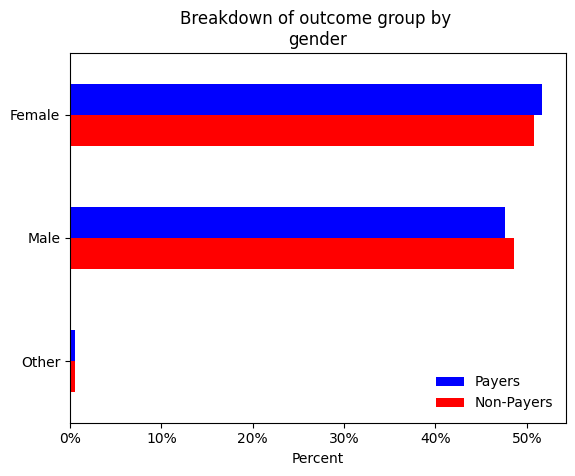

None

Breakdown of outcome group by 
marital_status
loan_paid_back_recoded marital_status  Non-Payers  Payers  percent_payers  \
2                              Single       58094  230749            48.6   
1                             Married       55685  221554            46.7   
0                            Divorced        4334   16978             3.6   
3                             Widowed        1387    5213             1.1   

loan_paid_back_recoded  percent_non_payers  
2                                     48.6  
1                                     46.6  
0                                      3.6  
3                                      1.2  


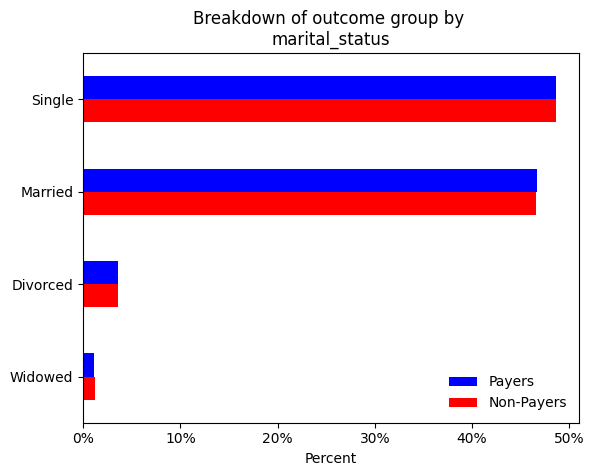

None

Breakdown of outcome group by 
education_level
loan_paid_back_recoded education_level  Non-Payers  Payers  percent_payers  \
0                           Bachelor's       59027  220579            46.5   
1                          High School       34938  148654            31.3   
2                             Master's       18401   74696            15.7   
3                                Other        5261   21416             4.5   
4                                  PhD        1873    9149             1.9   

loan_paid_back_recoded  percent_non_payers  
0                                     49.4  
1                                     29.2  
2                                     15.4  
3                                      4.4  
4                                      1.6  


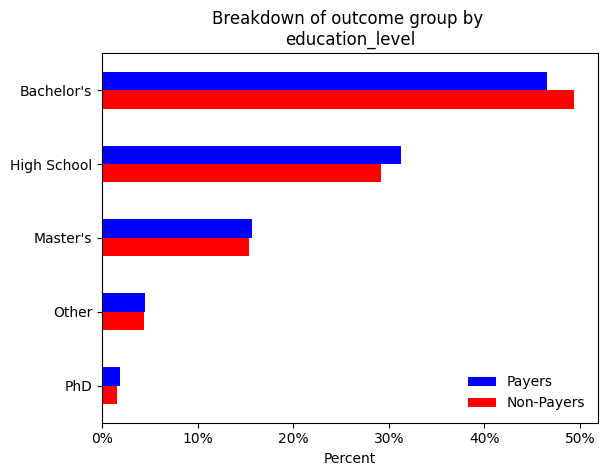

None

Breakdown of outcome group by 
employment_status
loan_paid_back_recoded employment_status  Non-Payers  Payers  percent_payers  \
0                               Employed       47703  402942            84.9   
2                          Self-employed        5329   47151             9.9   
1                                Retired          46   16407             3.5   
4                             Unemployed       57635    4850             1.0   
3                                Student        8787    3144             0.7   

loan_paid_back_recoded  percent_non_payers  
0                                     39.9  
2                                      4.5  
1                                      0.0  
4                                     48.2  
3                                      7.4  


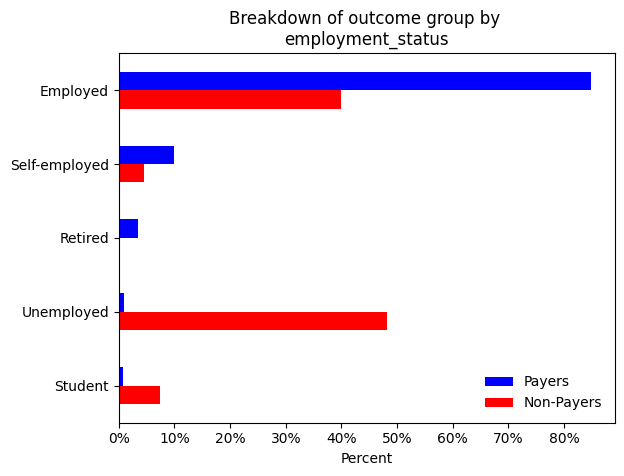

None

Breakdown of outcome group by 
loan_purpose
loan_paid_back_recoded        loan_purpose  Non-Payers  Payers  \
2                       Debt consolidation       65942  258753   
6                                    Other       12623   51251   
1                                      Car       11585   46523   
4                                     Home        7799   36319   
0                                 Business        6598   28705   
3                                Education        8169   28472   
5                                  Medical        5061   17745   
7                                 Vacation        1723    6726   

loan_paid_back_recoded  percent_payers  percent_non_payers  
2                                 54.5                55.2  
6                                 10.8                10.6  
1                                  9.8                 9.7  
4                                  7.7                 6.5  
0                                  6.0            

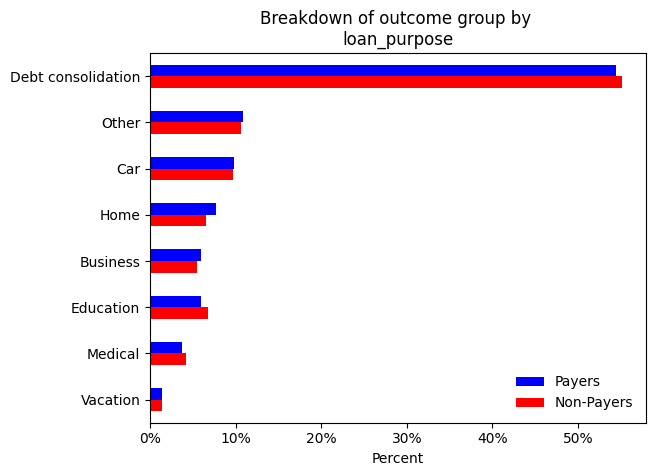

None

Breakdown of outcome group by 
grade_subgrade
loan_paid_back_recoded grade_subgrade  Non-Payers  Payers  percent_payers  \
12                                 C3        9626   49069            10.3   
13                                 C4        8730   47227            10.0   
11                                 C2        8103   46340             9.8   
10                                 C1        7466   45897             9.7   
14                                 C5        8197   45120             9.5   
15                                 D1        9928   27101             5.7   
17                                 D3       11156   25538             5.4   
18                                 D4       10012   25085             5.3   
16                                 D2        9608   24824             5.2   
19                                 D5        9213   22888             4.8   
6                                  B2         949   14218             3.0   
5                       

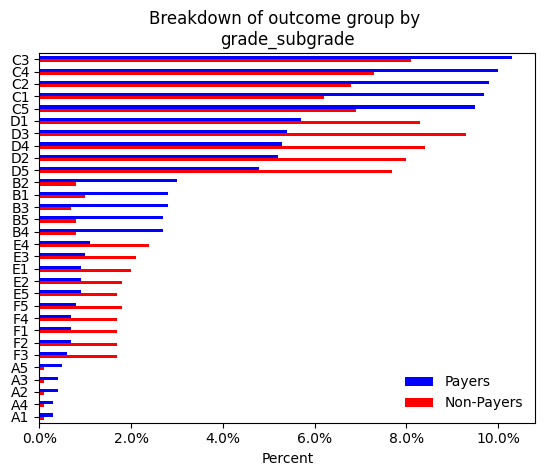

None


In [22]:
# loop over to see freq tables and plots
categorical_cols = data_train.select_dtypes(include='object').drop(
    'loan_paid_back_recoded', axis=1)

for col in categorical_cols:
    print(f"\nBreakdown of outcome group by \n{col}")
    freq_table = generate_freq_table(data_train, col)
    print(freq_table)
    plot = plot_categorical_cols(freq_table, col)
    print(plot)

- What we've learned / can expect in modelling

Next: data pre-processing